In [2]:
import os
from google.colab import userdata
import torch.optim as optim
import wandb
import sys
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch
import torchvision.transforms as T
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:

os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.environ['GITHUB_TOKEN'] = userdata.get('GITHUB_TOKEN')
os.environ['GITHUB_USERNAME'] = userdata.get('GITHUB_USERNAME')

!git clone https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git
%cd ML_hw_04_Facial-Expression-Recognition-Challenge

!pip install -q wandb kaggle


wandb.login(key=os.environ['WANDB_API_KEY'])

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(os.environ['KAGGLE_KEY'])

os.makedirs('/content/data', exist_ok=True)
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p /content/data
!unzip -q -o /content/data/*.zip -d /content/data

sys.path.append('/content/ML_hw_04_Facial-Expression-Recognition-Challenge/src')
from dataset import FERDataset, load_data, EMOTION_LABELS

print("Setup complete!")

Cloning into 'ML_hw_04_Facial-Expression-Recognition-Challenge'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 64 (delta 27), reused 10 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 115.74 KiB | 2.18 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/ML_hw_04_Facial-Expression-Recognition-Challenge


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kgord23 (kgord23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


100% 285M/285M [00:01<00:00, 170MB/s]

Setup complete!


In [4]:

train, val, test=load_data('/content/data/train.csv')
print("Train:", train.shape, "Val:", val.shape, "Test:", test.shape)

class_counts = train['emotion'].value_counts().sort_index().values
print("Class counts:", class_counts)
sample_weights = 1.0 / class_counts[train['emotion'].values]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

train_data=FERDataset(train)
val_data=FERDataset(val)
test_data=FERDataset(test)

BATCH_SIZE=64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train: (20095, 2) Val: (4307, 2) Test: (4307, 2)
Class counts: [2797  306 2867 5051 3380 2219 3475]
Train batches: 314
Val batches: 68
Test batches: 68


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

%matplotlib inline

def evaluate_model(model, val_loader, title="Confusion Matrix"):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())


    print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))


    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, cmap='Blues', linewidths=0.5)

    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')


    plt.show()

    return all_preds, all_labels

In [7]:
class BalancedDeeperCNN(nn.Module):
    def __init__(self, num_classes=7, dropout_p=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [8]:
def train_model(model, train_loader, val_loader, config, group_name, run_name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'],
                             weight_decay=config.get('weight_decay', 0))

    scheduler = None
    if config.get('scheduler') == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    run = wandb.init(project="facial-expression-recognition", group=group_name, name=run_name, config=config)

    best_val_loss = float('inf')
    patience_counter = 0
    early_stop_patience = config.get('early_stop_patience', 4)

    for epoch in range(config['epochs']):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        wandb.log({"epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc,
                   "val_loss": val_loss, "val_acc": val_acc, "lr": current_lr})
        print(f"Epoch {epoch+1}/{config['epochs']} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

        if scheduler:
            scheduler.step(val_loss)

        if config.get('early_stopping'):
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = model.state_dict()
            else:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    model.load_state_dict(best_model_state)
                    break

    wandb.finish()
    return model

In [9]:
model_check = BalancedDeeperCNN(dropout_p=0.3)
sample_batch, sample_labels = next(iter(train_loader))
output = model_check(sample_batch)
print("Output shape:", output.shape)

criterion = nn.CrossEntropyLoss()
loss = criterion(output, sample_labels)
print("Loss:", loss.item(), "| Expected ~", torch.log(torch.tensor(7.0)).item())

Output shape: torch.Size([64, 7])
Loss: 2.0348968505859375 | Expected ~ 1.9459102153778076


In [10]:
small_subset = train.sample(n=200, random_state=42)
small_dataset = FERDataset(small_subset, transform=train_transform)
small_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

config_sanity3 = {
    "architecture": "DeeperCNN-Balanced-sanity",
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 20,
    "optimizer": "Adam",
    "dropout": 0.3,
    "weight_decay": 0,
    "scheduler": "None",
    "early_stopping": False
}

model_sanity3 = BalancedDeeperCNN(dropout_p=0.3)
model_sanity3 = train_model(model_sanity3, small_loader, small_loader, config_sanity3,
                             group_name="sanity-checks",
                             run_name="architecture3-overfit-200-samples")

Epoch 1/20 | Train Loss: 3.8631, Train Acc: 0.1800 | Val Loss: 1.8594, Val Acc: 0.2550 | LR: 0.001000
Epoch 2/20 | Train Loss: 2.0289, Train Acc: 0.3050 | Val Loss: 1.8410, Val Acc: 0.2600 | LR: 0.001000
Epoch 3/20 | Train Loss: 1.9008, Train Acc: 0.2850 | Val Loss: 1.8579, Val Acc: 0.2500 | LR: 0.001000
Epoch 4/20 | Train Loss: 1.7798, Train Acc: 0.2550 | Val Loss: 1.8212, Val Acc: 0.2950 | LR: 0.001000
Epoch 5/20 | Train Loss: 1.7546, Train Acc: 0.3000 | Val Loss: 1.7257, Val Acc: 0.2900 | LR: 0.001000
Epoch 6/20 | Train Loss: 1.6968, Train Acc: 0.3200 | Val Loss: 1.7355, Val Acc: 0.3250 | LR: 0.001000
Epoch 7/20 | Train Loss: 1.6621, Train Acc: 0.3350 | Val Loss: 1.5953, Val Acc: 0.3400 | LR: 0.001000
Epoch 8/20 | Train Loss: 1.6146, Train Acc: 0.3850 | Val Loss: 1.5406, Val Acc: 0.3550 | LR: 0.001000
Epoch 9/20 | Train Loss: 1.6310, Train Acc: 0.3550 | Val Loss: 1.5411, Val Acc: 0.3900 | LR: 0.001000
Epoch 10/20 | Train Loss: 1.5212, Train Acc: 0.3800 | Val Loss: 1.5095, Val Acc: 0

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▃▃▄▄▄▅▅▅▆▅▆▇▆▆▆███
train_loss,█▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▁▁▂▂▃▃▃▄▄▅▅▅▆▆▅▇▇▇█
val_loss,████▇▇▅▅▅▄▃▃▃▃▂▃▂▂▁▁
epoch,20
lr,0.001
train_acc,0.505
train_loss,1.32495
val_acc,0.58


In [11]:
train_data_r1 = FERDataset(train)  # NO transform
train_loader_r1 = DataLoader(train_data_r1, batch_size=64, sampler=sampler)

config_a3_r1 = {
    "architecture": "DeeperCNN-Balanced", "learning_rate": 0.0005, "batch_size": 64,
    "epochs": 25, "optimizer": "Adam", "dropout": 0.3, "weight_decay": 0,
    "scheduler": "ReduceLROnPlateau", "early_stopping": True, "early_stop_patience": 4,
    "weighted_sampling": True, "augmentation": "none"
}

model_a3_r1 = BalancedDeeperCNN(dropout_p=0.3)
model_a3_r1 = train_model(model_a3_r1, train_loader_r1, val_loader, config_a3_r1,
                           group_name="architecture-3-balanced-augmented",
                           run_name="weighted-sampling-only")

Epoch 1/25 | Train Loss: 1.7403, Train Acc: 0.3196 | Val Loss: 1.5362, Val Acc: 0.4096 | LR: 0.000500
Epoch 2/25 | Train Loss: 1.3658, Train Acc: 0.4789 | Val Loss: 1.3417, Val Acc: 0.4834 | LR: 0.000500
Epoch 3/25 | Train Loss: 1.1840, Train Acc: 0.5472 | Val Loss: 1.3288, Val Acc: 0.4862 | LR: 0.000500
Epoch 4/25 | Train Loss: 1.0932, Train Acc: 0.5805 | Val Loss: 1.2326, Val Acc: 0.5217 | LR: 0.000500
Epoch 5/25 | Train Loss: 1.0207, Train Acc: 0.6134 | Val Loss: 1.2240, Val Acc: 0.5356 | LR: 0.000500
Epoch 6/25 | Train Loss: 0.9455, Train Acc: 0.6400 | Val Loss: 1.2087, Val Acc: 0.5401 | LR: 0.000500
Epoch 7/25 | Train Loss: 0.8970, Train Acc: 0.6633 | Val Loss: 1.1819, Val Acc: 0.5528 | LR: 0.000500
Epoch 8/25 | Train Loss: 0.8385, Train Acc: 0.6797 | Val Loss: 1.2276, Val Acc: 0.5475 | LR: 0.000500
Epoch 9/25 | Train Loss: 0.7759, Train Acc: 0.7093 | Val Loss: 1.2536, Val Acc: 0.5366 | LR: 0.000500
Epoch 10/25 | Train Loss: 0.7284, Train Acc: 0.7272 | Val Loss: 1.2923, Val Acc: 0

epoch,▁▂▂▃▄▅▅▆▇▇█
lr,██████████▁
train_acc,▁▃▄▅▆▆▆▇▇▇█
train_loss,█▆▅▄▄▃▃▂▂▂▁
val_acc,▁▅▅▆▇▇██▇▇█
val_loss,█▄▄▂▂▂▁▂▂▃▃
epoch,11
lr,0.00025
train_acc,0.77567
train_loss,0.61224
val_acc,0.55259


              precision    recall  f1-score   support

       Angry       0.48      0.43      0.45       599
     Disgust       0.71      0.45      0.55        65
        Fear       0.38      0.42      0.40       615
       Happy       0.76      0.75      0.76      1082
         Sad       0.43      0.36      0.39       725
    Surprise       0.71      0.72      0.72       476
     Neutral       0.46      0.56      0.51       745

    accuracy                           0.55      4307
   macro avg       0.56      0.53      0.54      4307
weighted avg       0.55      0.55      0.55      4307



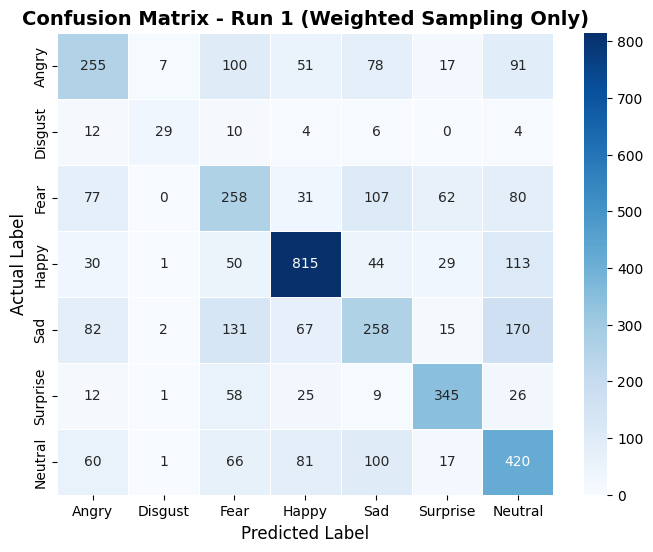

In [14]:

_ = evaluate_model(model_a3_r1, val_loader, title="Confusion Matrix - Run 1 (Weighted Sampling Only)")

In [15]:
train_data_r2 = FERDataset(train, transform=train_transform)
train_loader_r2 = DataLoader(train_data_r2, batch_size=64, shuffle=True)  # normal shuffle, no sampler

config_a3_r2 = {
    "architecture": "DeeperCNN-Balanced", "learning_rate": 0.0005, "batch_size": 64,
    "epochs": 25, "optimizer": "Adam", "dropout": 0.3, "weight_decay": 0,
    "scheduler": "ReduceLROnPlateau", "early_stopping": True, "early_stop_patience": 4,
    "weighted_sampling": False, "augmentation": "flip+rotation+translation"
}

model_a3_r2 = BalancedDeeperCNN(dropout_p=0.3)
model_a3_r2 = train_model(model_a3_r2, train_loader_r2, val_loader, config_a3_r2,
                           group_name="architecture-3-balanced-augmented",
                           run_name="augmentation-only")

Epoch 1/25 | Train Loss: 1.7020, Train Acc: 0.3193 | Val Loss: 1.5274, Val Acc: 0.4026 | LR: 0.000500
Epoch 2/25 | Train Loss: 1.4818, Train Acc: 0.4268 | Val Loss: 1.3714, Val Acc: 0.4609 | LR: 0.000500
Epoch 3/25 | Train Loss: 1.3933, Train Acc: 0.4684 | Val Loss: 1.2945, Val Acc: 0.5027 | LR: 0.000500
Epoch 4/25 | Train Loss: 1.3492, Train Acc: 0.4855 | Val Loss: 1.3176, Val Acc: 0.4885 | LR: 0.000500
Epoch 5/25 | Train Loss: 1.3078, Train Acc: 0.5024 | Val Loss: 1.2375, Val Acc: 0.5250 | LR: 0.000500
Epoch 6/25 | Train Loss: 1.2870, Train Acc: 0.5108 | Val Loss: 1.2178, Val Acc: 0.5261 | LR: 0.000500
Epoch 7/25 | Train Loss: 1.2597, Train Acc: 0.5209 | Val Loss: 1.1960, Val Acc: 0.5363 | LR: 0.000500
Epoch 8/25 | Train Loss: 1.2372, Train Acc: 0.5317 | Val Loss: 1.1602, Val Acc: 0.5519 | LR: 0.000500
Epoch 9/25 | Train Loss: 1.2242, Train Acc: 0.5340 | Val Loss: 1.1502, Val Acc: 0.5531 | LR: 0.000500
Epoch 10/25 | Train Loss: 1.2059, Train Acc: 0.5409 | Val Loss: 1.1373, Val Acc: 0

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,█████████████████████▁▁▁▁
train_acc,▁▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████
train_loss,█▆▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▄▅▅▅▆▆▆▆▇▇▆▇▇▇▇▆▇▆████
val_loss,█▆▅▅▄▄▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁
epoch,25
lr,0.00025
train_acc,0.61498
train_loss,1.01906
val_acc,0.59972


              precision    recall  f1-score   support

       Angry       0.57      0.44      0.50       599
     Disgust       0.79      0.23      0.36        65
        Fear       0.49      0.30      0.37       615
       Happy       0.75      0.88      0.81      1082
         Sad       0.41      0.66      0.50       725
    Surprise       0.76      0.72      0.74       476
     Neutral       0.62      0.47      0.53       745

    accuracy                           0.60      4307
   macro avg       0.63      0.53      0.54      4307
weighted avg       0.61      0.60      0.59      4307



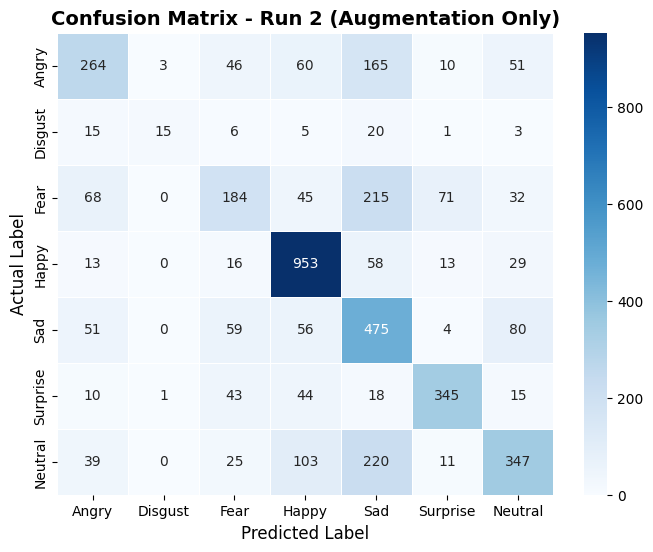

In [16]:

_ = evaluate_model(model_a3_r2, val_loader, title="Confusion Matrix - Run 2 (Augmentation Only)")

In [9]:
train_data_r3 = FERDataset(train, transform=train_transform)
train_loader_r3 = DataLoader(train_data_r3, batch_size=64, sampler=sampler)

config_a3_r3 = {
    "architecture": "DeeperCNN-Balanced", "learning_rate": 0.0005, "batch_size": 64,
    "epochs": 25, "optimizer": "Adam", "dropout": 0.3, "weight_decay": 0,
    "scheduler": "ReduceLROnPlateau", "early_stopping": True, "early_stop_patience": 4,
    "weighted_sampling": True, "augmentation": "flip+rotation+translation"
}

model_a3_r3 = BalancedDeeperCNN(dropout_p=0.3)
model_a3_r3 = train_model(model_a3_r3, train_loader_r3, val_loader, config_a3_r3,
                           group_name="architecture-3-balanced-augmented",
                           run_name="sampling-and-augmentation")

Epoch 1/25 | Train Loss: 1.8332, Train Acc: 0.2661 | Val Loss: 1.6533, Val Acc: 0.3492 | LR: 0.000500
Epoch 2/25 | Train Loss: 1.6127, Train Acc: 0.3764 | Val Loss: 1.5571, Val Acc: 0.3898 | LR: 0.000500
Epoch 3/25 | Train Loss: 1.4915, Train Acc: 0.4345 | Val Loss: 1.3630, Val Acc: 0.4658 | LR: 0.000500
Epoch 4/25 | Train Loss: 1.4352, Train Acc: 0.4537 | Val Loss: 1.3187, Val Acc: 0.4848 | LR: 0.000500
Epoch 5/25 | Train Loss: 1.3725, Train Acc: 0.4825 | Val Loss: 1.3125, Val Acc: 0.4839 | LR: 0.000500
Epoch 6/25 | Train Loss: 1.3382, Train Acc: 0.4858 | Val Loss: 1.3403, Val Acc: 0.4892 | LR: 0.000500
Epoch 7/25 | Train Loss: 1.3103, Train Acc: 0.5029 | Val Loss: 1.2267, Val Acc: 0.5250 | LR: 0.000500
Epoch 8/25 | Train Loss: 1.2715, Train Acc: 0.5170 | Val Loss: 1.2195, Val Acc: 0.5277 | LR: 0.000500
Epoch 9/25 | Train Loss: 1.2492, Train Acc: 0.5263 | Val Loss: 1.2078, Val Acc: 0.5363 | LR: 0.000500
Epoch 10/25 | Train Loss: 1.2341, Train Acc: 0.5295 | Val Loss: 1.2126, Val Acc: 0

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,███████████████████▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▂▄▅▅▅▆▆▇▇▆▆▇▇▆▇▆▇▇█▇████
val_loss,█▇▄▄▄▄▃▃▃▃▂▃▂▂▃▂▃▂▂▂▂▁▁▁▁
epoch,25
lr,0.00025
train_acc,0.61926
train_loss,1.00411
val_acc,0.58695


              precision    recall  f1-score   support

       Angry       0.53      0.48      0.51       599
     Disgust       0.54      0.68      0.60        65
        Fear       0.43      0.26      0.33       615
       Happy       0.82      0.78      0.80      1082
         Sad       0.43      0.51      0.47       725
    Surprise       0.69      0.80      0.74       476
     Neutral       0.50      0.59      0.54       745

    accuracy                           0.59      4307
   macro avg       0.56      0.59      0.57      4307
weighted avg       0.59      0.59      0.58      4307



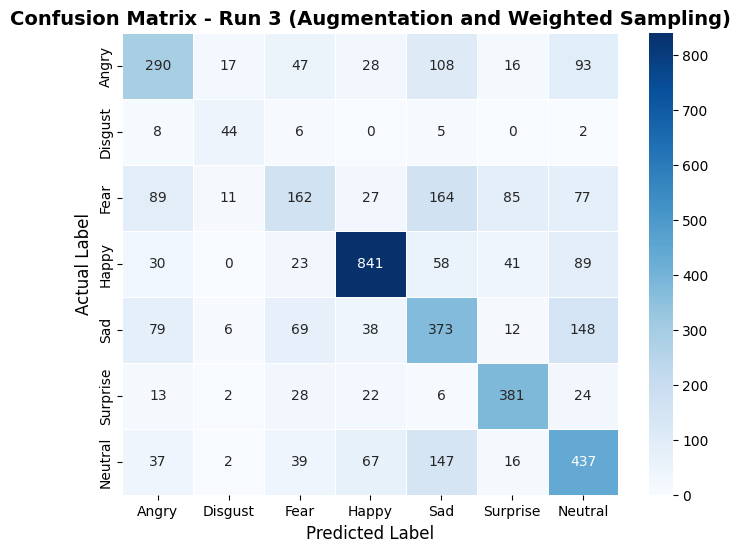

In [10]:

_ = evaluate_model(model_a3_r3, val_loader, title="Confusion Matrix - Run 3 (Augmentation and Weighted Sampling)")